In [1]:
from pathlib import Path
import pandas as pd
from pesco.io import load_sources, prepare_psd

from pesco.experimental.clustering import (
    compute_clusters,
    identify_small_clusters,
    get_no_peak,
)
from pesco.experimental.peak_testing import (
    cutintervals,
    test_lobes,
    test_regions,
)
from pesco.experimental.plotting import (
    plot_clusters,
    plot_histogram,
    plot_lobes,
    plot_regions,
)

seed = 3

In [2]:
PROJECT_DIR = Path("/Users/daniel/PhD/spectral-comparison/code/")

DATA_PATH_SOURCES = Path(f"{PROJECT_DIR}/data/Mantini2018")

DATA_PATH_IEEG = Path(f"{PROJECT_DIR}/data/Frauscher2018")  # TODO: fill in

matfile = DATA_PATH_IEEG / "WakefulnessMatlabFile.mat"
region_dict_file = DATA_PATH_IEEG / "RegionInformation.csv"


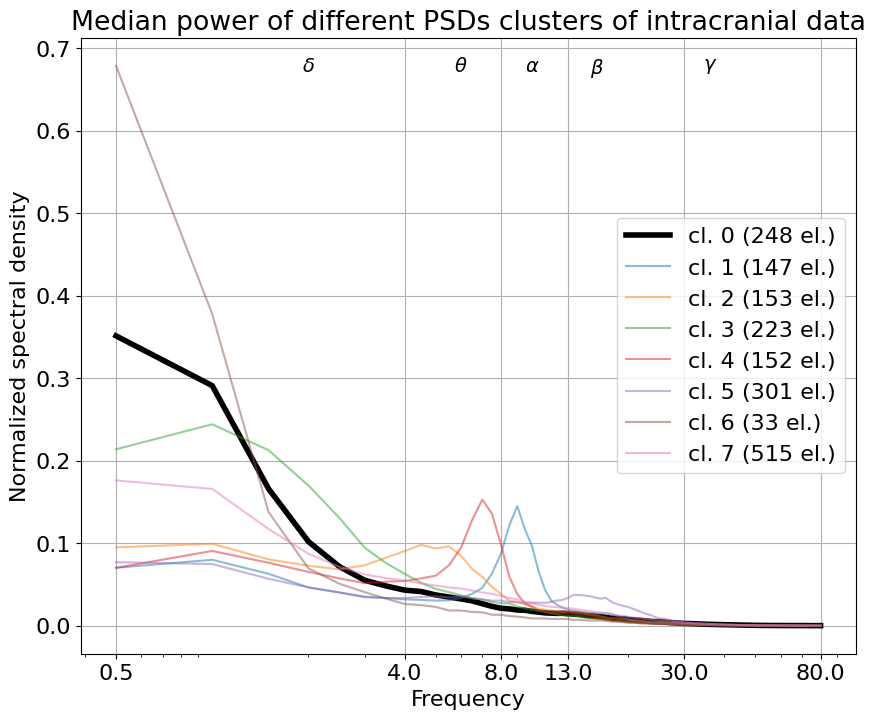

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Median power of different PSDs clusters of intracranial data'}, xlabel='Frequency', ylabel='Normalized spectral density'>)

In [3]:
dataset = "intracranial data"
SUMMARY = "median"  # paper-faithful; switch to "median" for A/B
f, psd = prepare_psd(matfile, region_dict_file)

# Stage 2: cluster
psd_clust = compute_clusters(psd.drop(["Region name", "Lobe"], axis=1), n_clusters=8, random_seed=seed)
smal = identify_small_clusters(psd_clust, summary=SUMMARY)
no_peak_df, _ = get_no_peak(psd_clust, smal, summary=SUMMARY)

# Stage 3: bin and test
colbin, _ = cutintervals(f)
sig_lobes = test_lobes(no_peak_df, psd, colbin)
sig_regions = test_regions(no_peak_df, psd, colbin)

# Stage 4: plot any of these independently, in any order
plot_clusters(psd_clust, f, dataset, smal, nopeak=smal[0], summary=SUMMARY)

Creating RawArray with float64 data, n_channels=1444, n_times=62689
    Range : 0 ... 62688 =      0.000 ...   313.440 secs
Ready.


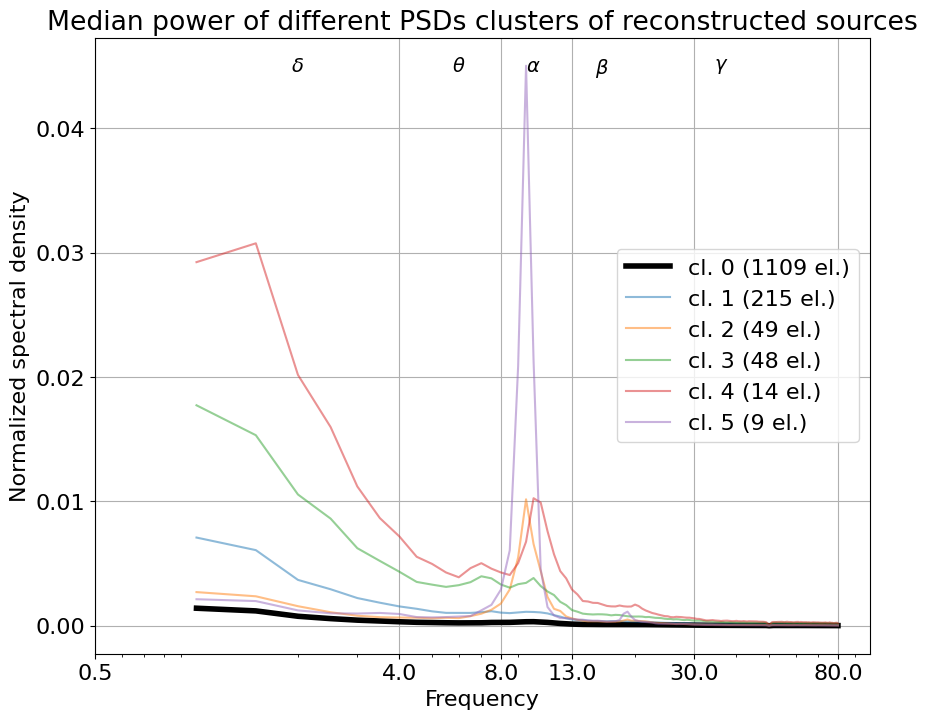

ValueError: 'x' has size 44, but 'y1' has an unequal size of 42

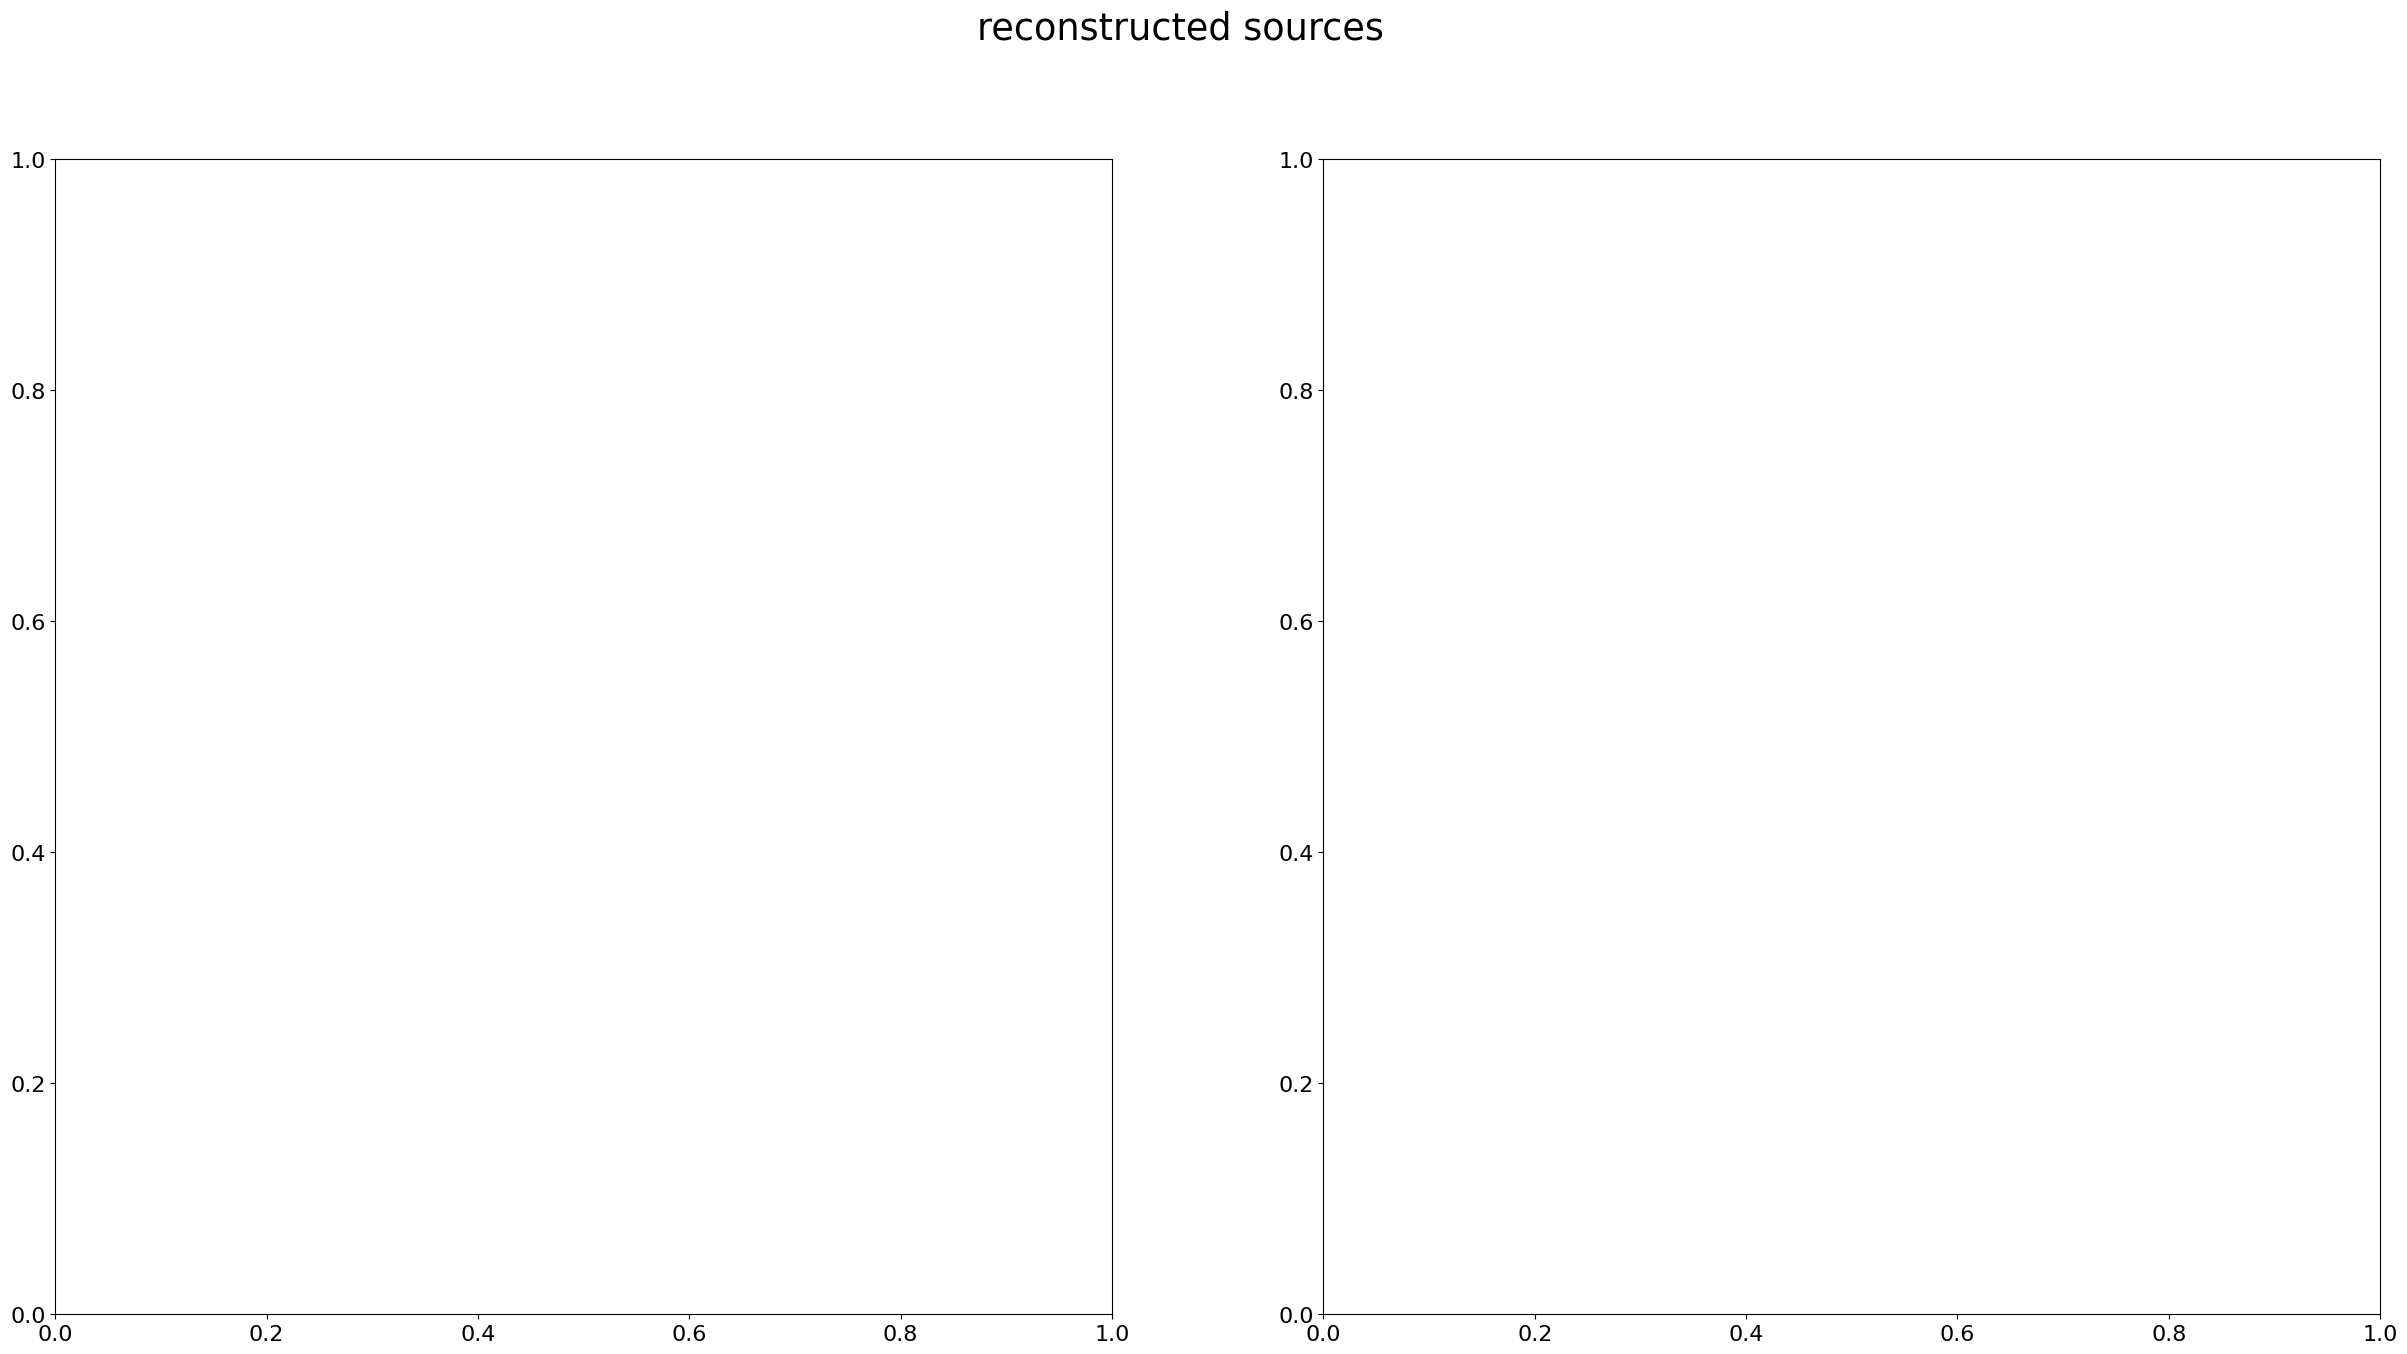

In [24]:
from pesco.preprocess import compute_psd
from pesco.experimental.clustering import (
    compute_clusters, identify_small_clusters, get_no_peak,
)
from pesco.experimental.peak_testing import cutintervals, test_lobes
from pesco.experimental.plotting import (
    plot_clusters, plot_histogram, plot_lobes,
)

# Sources
dataset = "reconstructed sources"
SUMMARY = "median"
FREQ_RANGE = (1.0, 80.0)

raw_src, result = load_sources(DATA_PATH_SOURCES)

f, psd_source = compute_psd(
    raw_src.get_data(), raw_src.info["sfreq"],
    fmin=FREQ_RANGE[0], fmax=FREQ_RANGE[1],
)
# No normalize_psd — average spectrum already removed in preprocessing
psd_source_df = pd.DataFrame(psd_source, index=raw_src.info["ch_names"], columns=f)

Y = psd_source_df.join(result)

# Stage 2: cluster
psd_clust = compute_clusters(
    Y.drop(["Region name", "Lobe", "region_number", "dataset"], axis=1),
    n_clusters=6, random_seed=seed,
)
smal = identify_small_clusters(psd_clust, summary=SUMMARY)
no_peak_df, _ = get_no_peak(psd_clust, smal, summary=SUMMARY)

# Stage 3: bin and test
colbin, _ = cutintervals(f)
psd = Y.drop(["region_number", "dataset"], axis=1)
sig_lobes = test_lobes(no_peak_df, psd, colbin)

# Stage 4: plot
plot_clusters(psd_clust, f, dataset, smal, nopeak=smal[0] if smal else None, summary=SUMMARY)
plot_histogram(psd, colbin, dataset, summary=SUMMARY)
plot_lobes(psd_clust, psd, f, smal, dataset, sig_lobes, show=True, summary=SUMMARY)

In [ ]:
from pesco.preprocess import compute_psd, normalize_psd
from pesco.experimental.clustering import (
    compute_clusters, identify_small_clusters, get_no_peak,
)
from pesco.experimental.peak_testing import cutintervals, test_lobes
from pesco.experimental.plotting import (
    plot_clusters, plot_histogram, plot_lobes,
)

# Sources
dataset = "reconstructed sources"
SUMMARY = "median"
FREQ_RANGE = (1.0, 80.0)

raw_src, result = load_sources(DATA_PATH_SOURCES)

f, psd_source = compute_psd(
    raw_src.get_data(), raw_src.info["sfreq"],
    fmin=FREQ_RANGE[0], fmax=FREQ_RANGE[1],
)
psd_source = normalize_psd(psd_source, f)

psd_source_df = pd.DataFrame(psd_source, index=raw_src.info["ch_names"], columns=f)

Y = psd_source_df.join(result)

# Stage 2: cluster
psd_clust = compute_clusters(
    Y.drop(["Region name", "Lobe", "region_number", "dataset"], axis=1),
    n_clusters=6, random_seed=seed,
)
smal = identify_small_clusters(psd_clust, summary=SUMMARY)
no_peak_df, _ = get_no_peak(psd_clust, smal, summary=SUMMARY)

# Stage 3: bin and test
colbin, _ = cutintervals(f)
psd = Y.drop(["region_number", "dataset"], axis=1)
sig_lobes = test_lobes(no_peak_df, psd, colbin)

# Stage 4: plot
#plot_clusters(psd_clust, f, dataset, smal, nopeak=smal[0] if smal else None, summary=SUMMARY)
plot_clusters(psd_clust, f, dataset, smal, nopeak=2, summary=SUMMARY)
plot_histogram(psd, colbin, dataset, summary=SUMMARY)
plot_lobes(psd_clust, psd, f, smal, dataset, sig_lobes, show=True, summary=SUMMARY)

In [21]:
cluster_medians = psd_clust.groupby("clusters").median()
print(cluster_medians.shape)            # should be (8, 160)
# plot them, or check the criterion manually:
for idx, row in cluster_medians.iterrows():
    others_max = cluster_medians.drop(idx).max()
    n_below = (row < others_max).sum()
    print(f"cluster {idx}: below max-of-others at {n_below}/160 frequencies")

(8, 160)
cluster 0: below max-of-others at 151/160 frequencies
cluster 1: below max-of-others at 159/160 frequencies
cluster 2: below max-of-others at 159/160 frequencies
cluster 3: below max-of-others at 154/160 frequencies
cluster 4: below max-of-others at 39/160 frequencies
cluster 5: below max-of-others at 153/160 frequencies
cluster 6: below max-of-others at 150/160 frequencies
cluster 7: below max-of-others at 155/160 frequencies


In [24]:
cluster_medians = psd_clust.groupby("clusters").median()
for idx, row in cluster_medians.iterrows():
    others_max = cluster_medians.drop(idx).max()
    n_below = (row < others_max).sum()
    print(f"cluster {idx}: below max-of-others at {n_below}/160 frequencies")

cluster 0: below max-of-others at 154/160 frequencies
cluster 1: below max-of-others at 158/160 frequencies
cluster 2: below max-of-others at 152/160 frequencies
cluster 3: below max-of-others at 152/160 frequencies
cluster 4: below max-of-others at 30/160 frequencies
cluster 5: below max-of-others at 154/160 frequencies


In [7]:


medians = psd_clust.groupby("clusters").median()
smal = identify_small_clusters(medians)
print("smal:", smal)
print("n channels per cluster:", psd_clust["clusters"].value_counts().sort_index())

smal: [2]
n channels per cluster: clusters
0    208
1    105
2    257
3    555
4     95
5     20
6    204
Name: count, dtype: int64


In [9]:
import numpy as np
medians = psd_clust.groupby("clusters").median()
for idx in medians.index:
    row = medians.loc[idx]
    max_others = medians.drop(idx).max()
    n_below = np.sum(row < max_others)
    print(f"cluster {idx}: {n_below}/{len(row)} freqs below max(others), "
          f"total power={row.sum():.3f}")

cluster 0: 30/160 freqs below max(others), total power=0.961
cluster 1: 159/160 freqs below max(others), total power=0.936
cluster 2: 160/160 freqs below max(others), total power=0.932
cluster 3: 151/160 freqs below max(others), total power=0.945
cluster 4: 152/160 freqs below max(others), total power=0.907
cluster 5: 154/160 freqs below max(others), total power=0.953
cluster 6: 154/160 freqs below max(others), total power=0.945


In [10]:
cluster_5_channels = psd_clust[psd_clust["clusters"] == 5].index
cluster_5_info = result.loc[cluster_5_channels]
print(cluster_5_info[["Region name", "Lobe"]].value_counts())

Region name                                   Lobe     
'Cuneus'                                      Occipital    4
'Angular gyrus'                               Parietal     2
'Calcarine cortex'                            Occipital    2
'Lingual gyrus and occipital fusiform gyrus'  Occipital    2
'Medial segment of precentral gyrus'          Frontal      2
'Posterior cingulate'                         Parietal     2
'Precuneus'                                   Parietal     2
'Superior and middle occipital gyri'          Occipital    2
'Fusiform and parahippocampal gyri'           Temporal     1
'Parietal operculum'                          Parietal     1
Name: count, dtype: int64


In [11]:
cluster_5_channels = psd_clust[psd_clust["clusters"] == 5].index
cluster_5_info = result.loc[cluster_5_channels].copy()

# parse the channel name
parsed = cluster_5_info.index.to_series().str.extract(
    r"(?P<subject>dataset\d+)_(?P<region_num>\d+)(?P<hemisphere>[RL])"
)
cluster_5_info["subject"] = parsed["subject"].values
cluster_5_info["hemisphere"] = parsed["hemisphere"].values

print(cluster_5_info[["subject", "hemisphere", "Region name", "Lobe"]])

                 subject hemisphere  \
dataset14_03R  dataset14          R   
dataset14_03L  dataset14          L   
dataset03_01R  dataset03          R   
dataset03_01L  dataset03          L   
dataset03_03R  dataset03          R   
dataset03_03L  dataset03          L   
dataset03_04R  dataset03          R   
dataset03_04L  dataset03          L   
dataset03_05R  dataset03          R   
dataset03_05L  dataset03          L   
dataset03_08R  dataset03          R   
dataset03_10R  dataset03          R   
dataset03_10L  dataset03          L   
dataset03_11R  dataset03          R   
dataset03_11L  dataset03          L   
dataset03_12R  dataset03          R   
dataset03_12L  dataset03          L   
dataset03_28R  dataset03          R   
dataset03_28L  dataset03          L   
dataset03_36R  dataset03          R   

                                                Region name       Lobe  
dataset14_03R                                      'Cuneus'  Occipital  
dataset14_03L                     

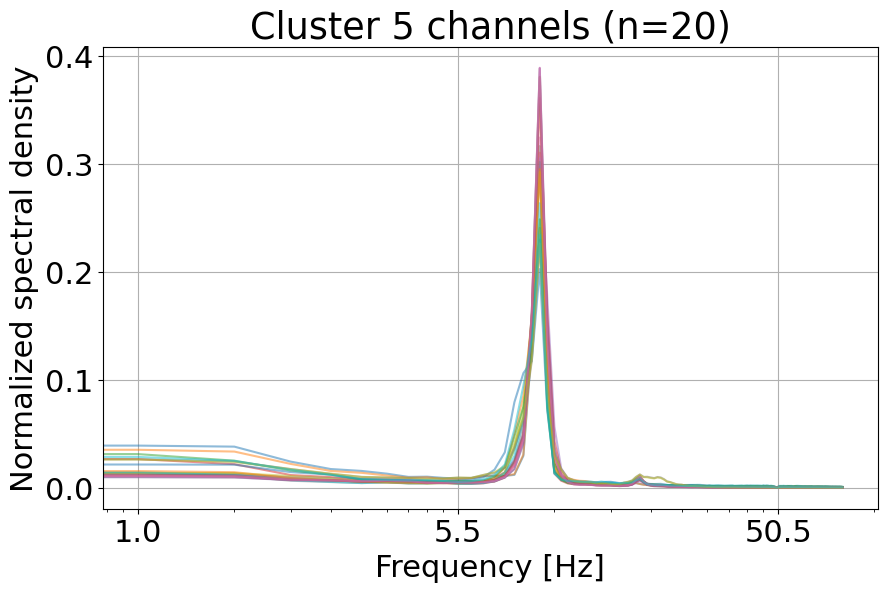

In [13]:
import matplotlib.pyplot as plt
cluster_5_channels = psd_clust[psd_clust["clusters"] == 5].index
psd_clust.loc[cluster_5_channels, f].T.plot(
    logx=True, figsize=(10, 6), legend=False, alpha=0.5
)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized spectral density")
plt.title(f"Cluster 5 channels (n={len(cluster_5_channels)})")
plt.grid()
plt.show()

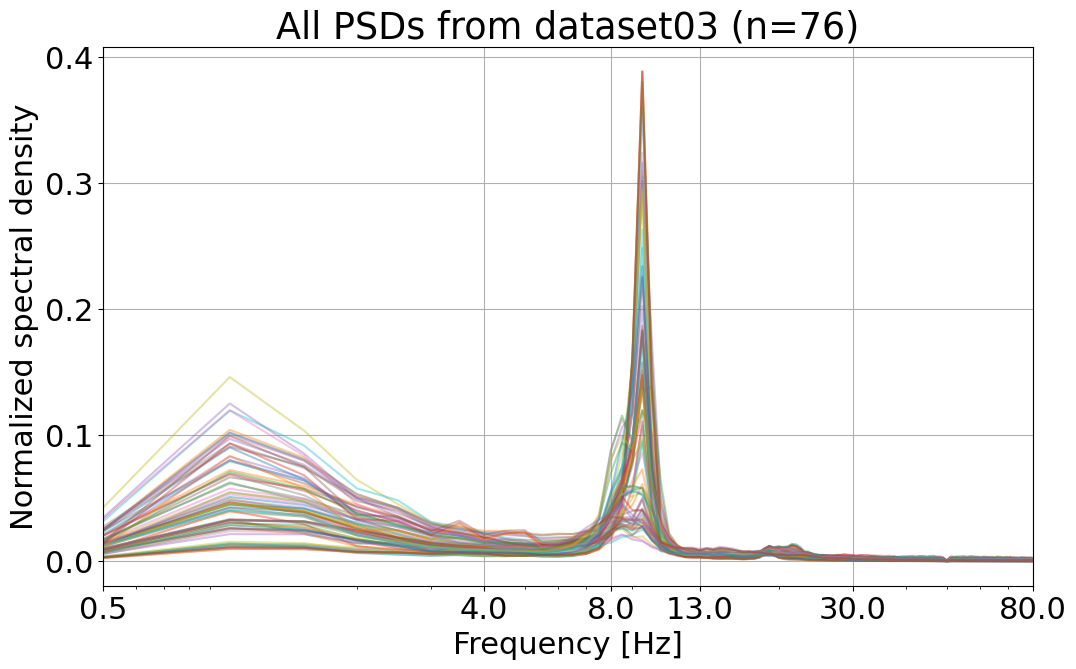

In [15]:
import matplotlib
import matplotlib.ticker
dataset03_channels = [ch for ch in psd_clust.index if ch.startswith("dataset03_")]

fig, ax = plt.subplots(figsize=(12, 7))
for ch in dataset03_channels:
    ax.semilogx(f, psd_clust.loc[ch, f], alpha=0.4)

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Normalized spectral density")
ax.set_title(f"All PSDs from dataset03 (n={len(dataset03_channels)})")
ax.set_xlim(0.5, 80)
ax.set_xticks([0.5, 4, 8, 13, 30, 80])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.grid()
plt.show()

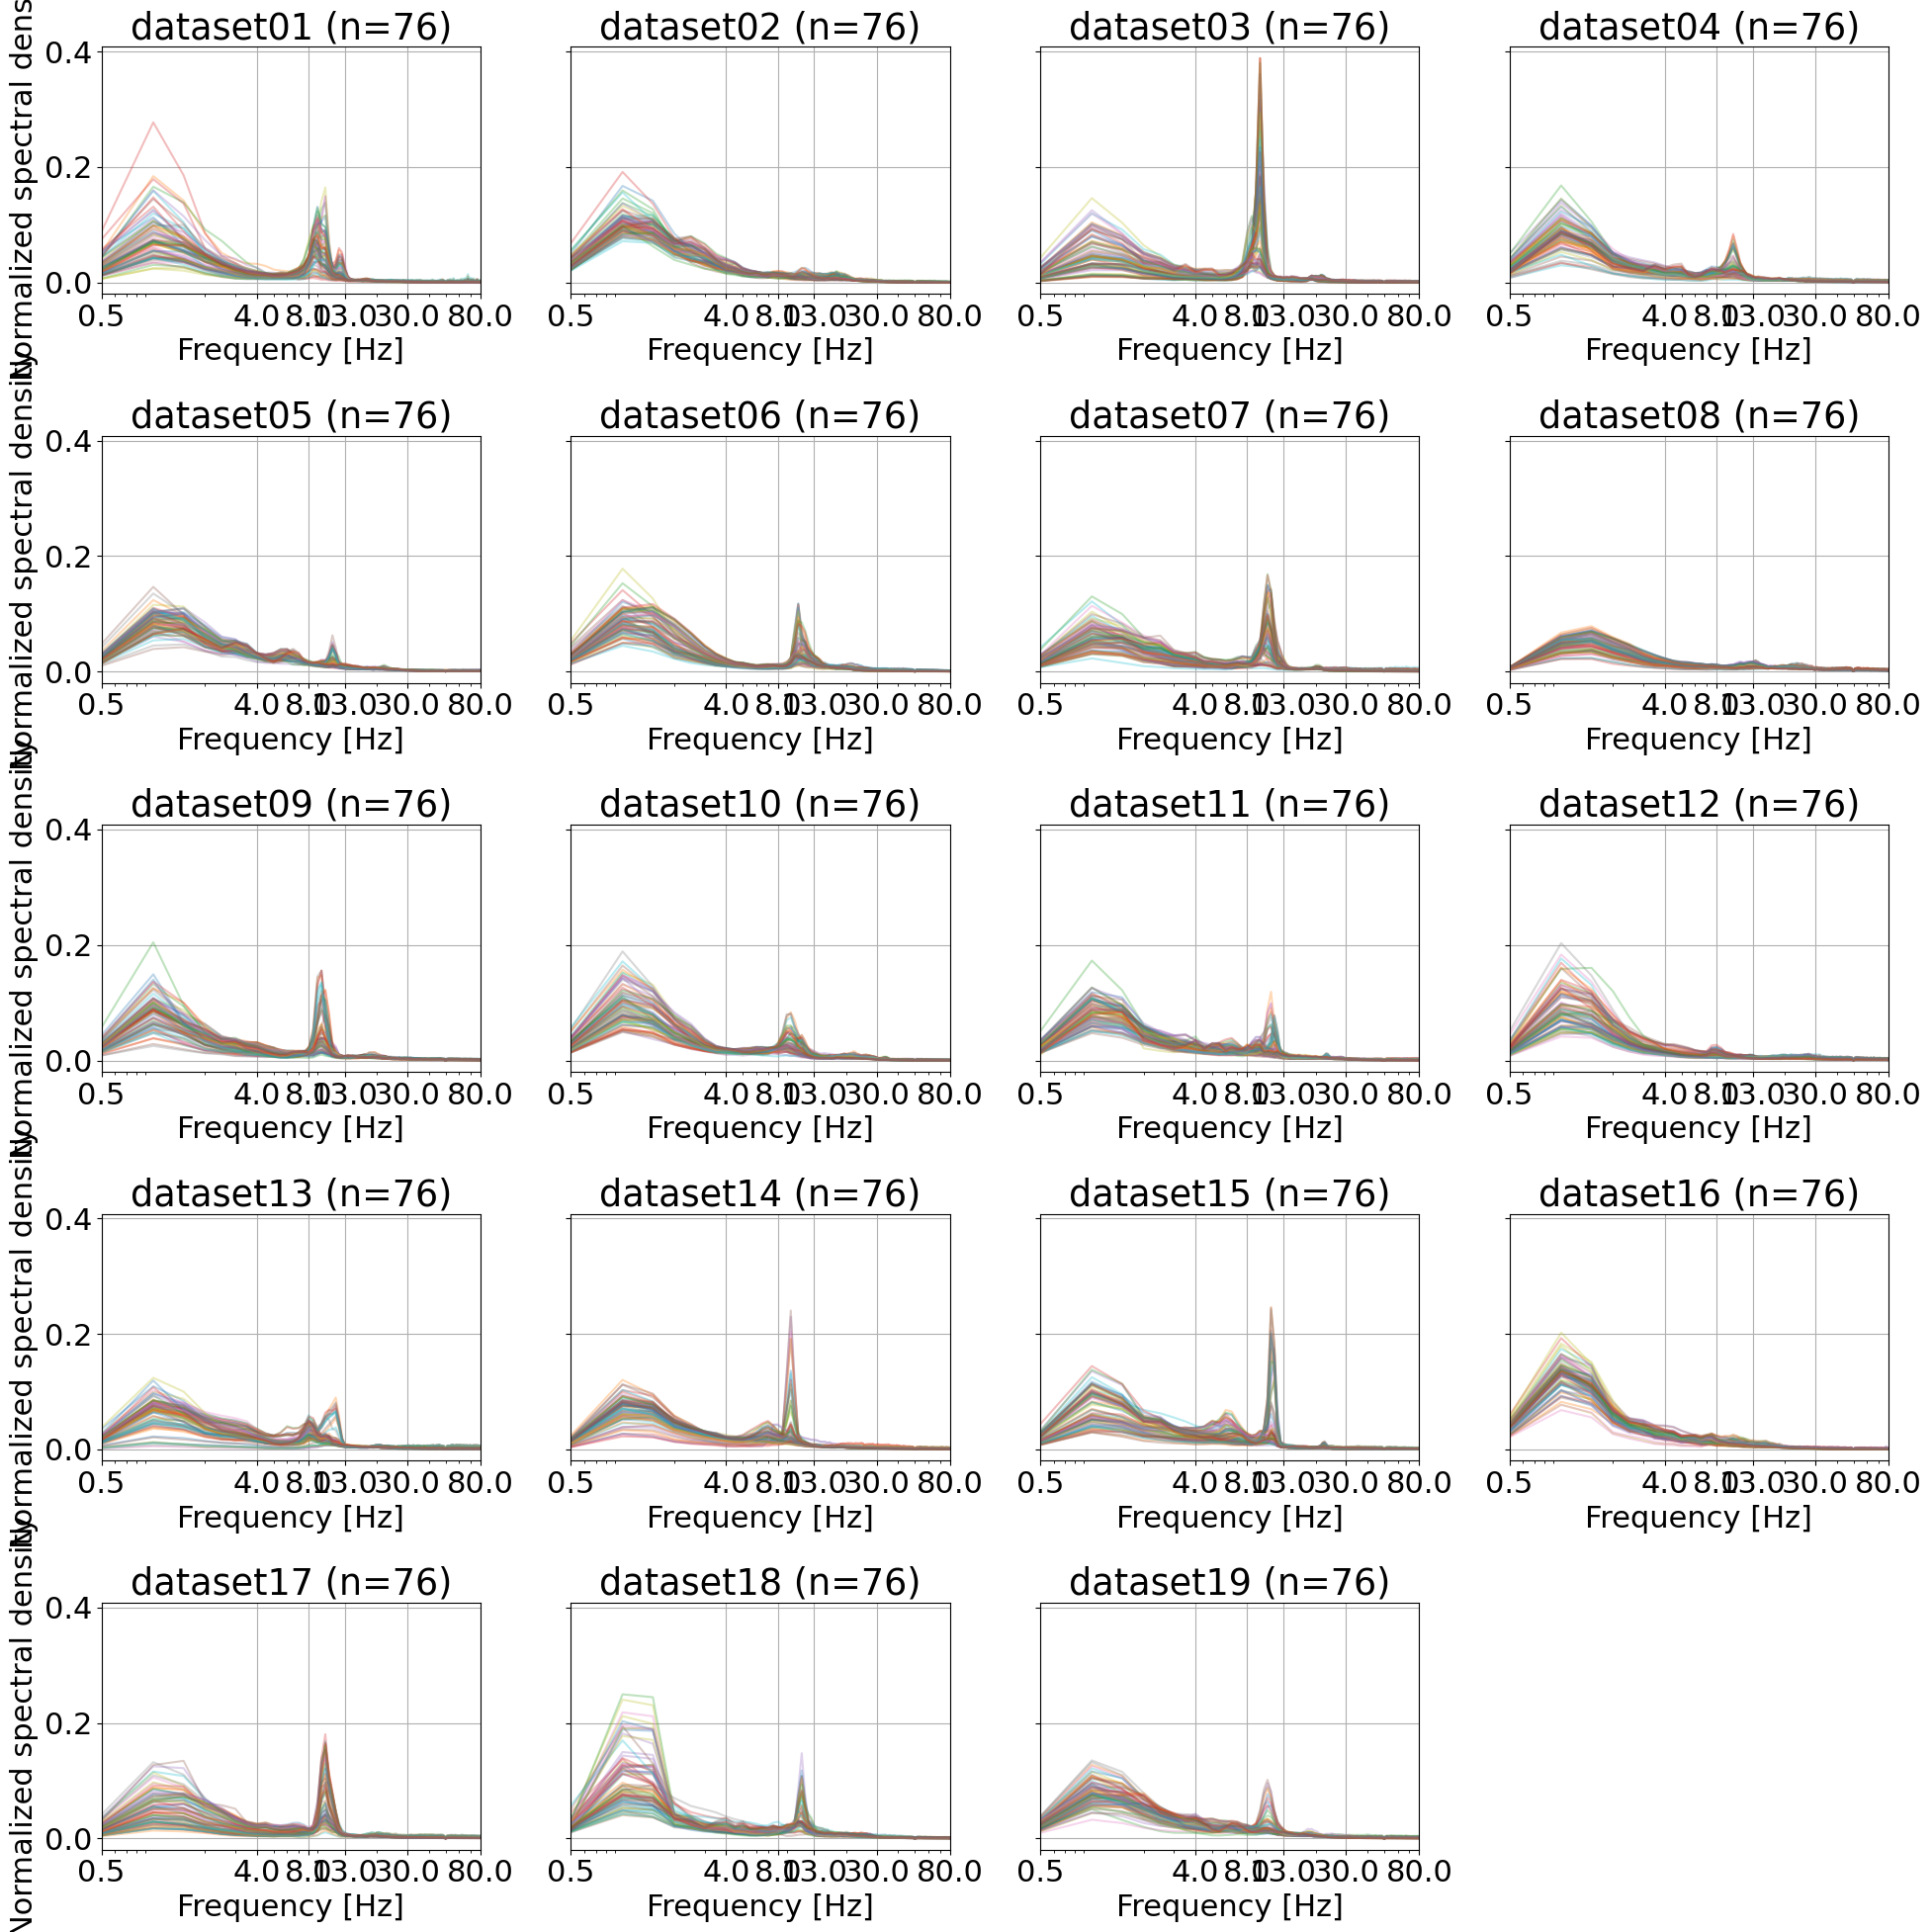

In [16]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker

subjects = sorted(set(ch.split("_")[0] for ch in psd_clust.index))

n_cols = 4
n_rows = -(-len(subjects) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, subj in zip(axes, subjects):
    chans = [ch for ch in psd_clust.index if ch.startswith(f"{subj}_")]
    for ch in chans:
        ax.semilogx(f, psd_clust.loc[ch, f], alpha=0.3)
    ax.set_title(f"{subj} (n={len(chans)})")
    ax.set_xlim(0.5, 80)
    ax.set_xticks([0.5, 4, 8, 13, 30, 80])
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid()
    ax.set_xlabel("Frequency [Hz]")

# hide unused subplots
for ax in axes[len(subjects):]:
    ax.set_visible(False)

for ax in axes[::n_cols]:
    ax.set_ylabel("Normalized spectral density")

plt.tight_layout()
plt.show()

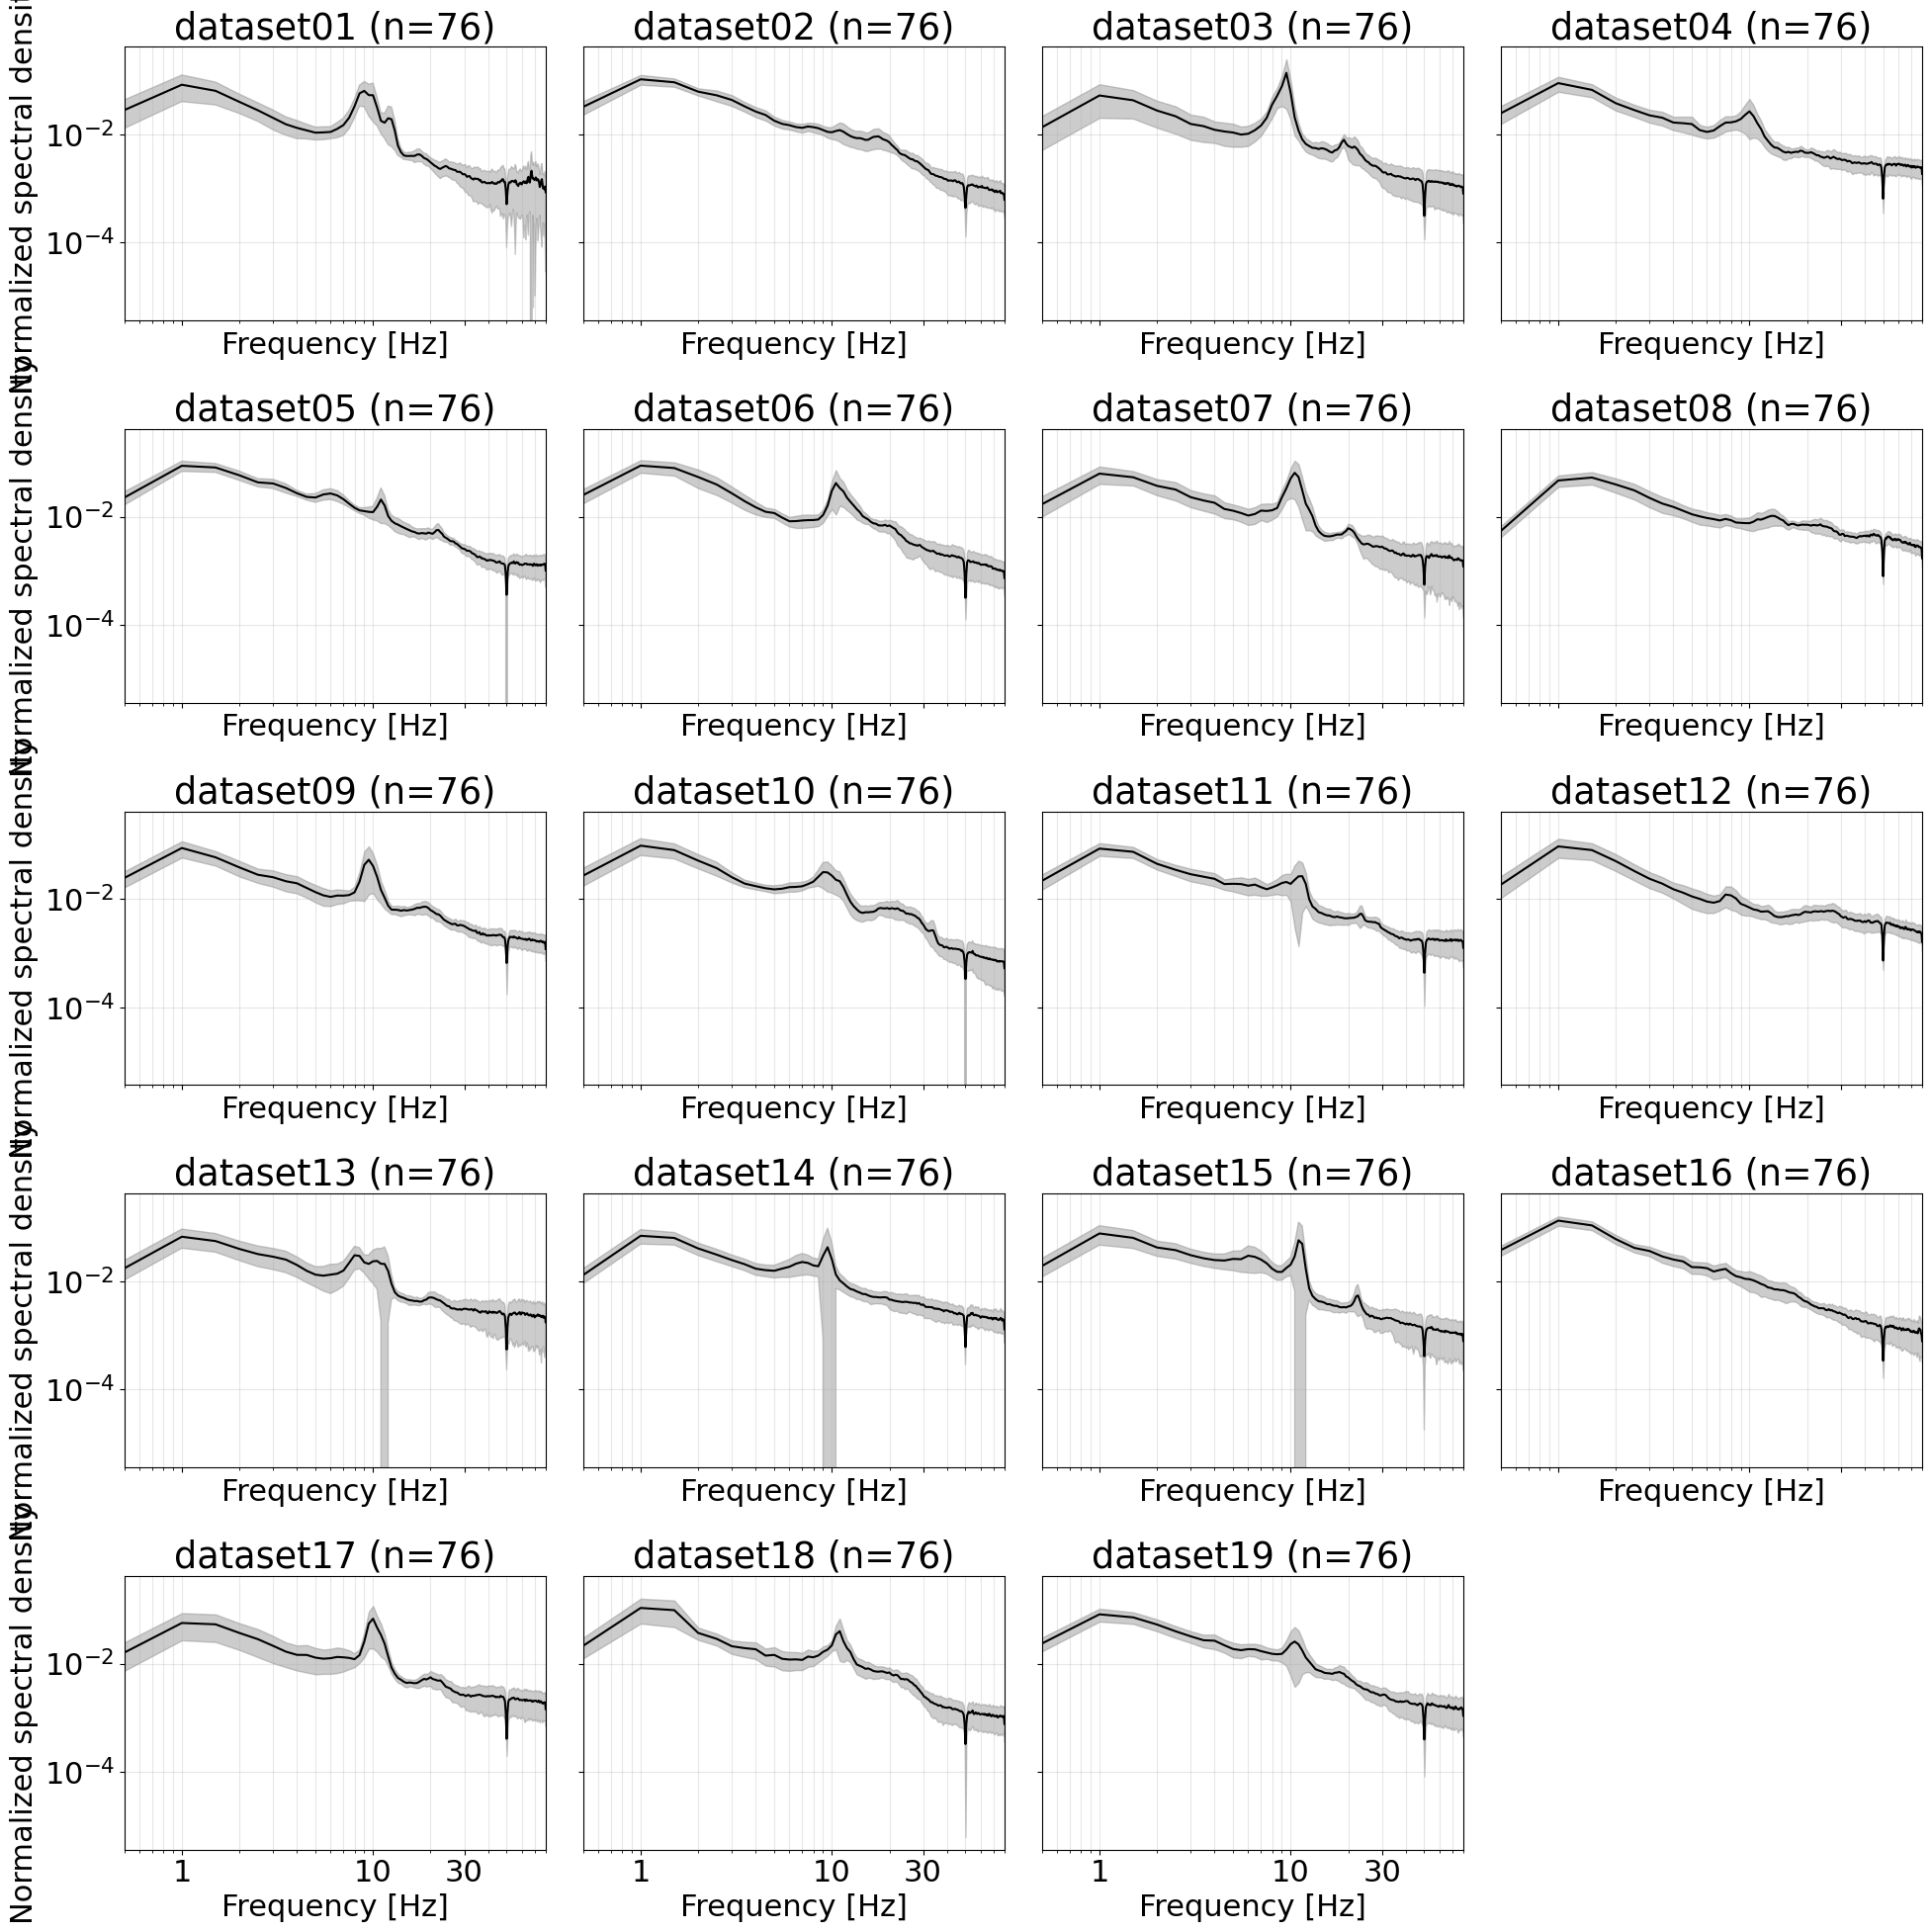

In [17]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np

subjects = sorted(set(ch.split("_")[0] for ch in psd_clust.index))

n_cols = 4
n_rows = -(-len(subjects) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, subj in zip(axes, subjects):
    chans = [ch for ch in psd_clust.index if ch.startswith(f"{subj}_")]
    data = psd_clust.loc[chans, f].values  # (n_channels, n_freqs)
    mean = data.mean(axis=0)
    std = data.std(axis=0)

    ax.loglog(f, mean, color="black", linewidth=1.5)
    ax.fill_between(f, mean - std, mean + std, color="gray", alpha=0.4)

    ax.set_title(f"{subj} (n={len(chans)})")
    ax.set_xlim(0.5, 80)
    ax.set_xticks([1, 10, 30])
    ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.grid(which="both", alpha=0.3)
    ax.set_xlabel("Frequency [Hz]")

for ax in axes[len(subjects):]:
    ax.set_visible(False)
for ax in axes[::n_cols]:
    ax.set_ylabel("Normalized spectral density")

plt.tight_layout()
plt.show()